In [94]:
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve


In [95]:
#carregando o dataset e dividindo em teste e treino

data = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2)

print(list(data.target_names))

['malignant', 'benign']


In [96]:
#escalando os dados

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [97]:
#criando e treinando o modelo

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=4)

In [98]:
#calculando algumas métricas

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test) 

print('Acurácia: ', accuracy_score(y_test, y_test_pred))
print('Recall: ', recall_score(y_test, y_test_pred))
print('Precisão: ', precision_score(y_test, y_test_pred))
print('Matriz de Confusão: ')
confusion_matrix(y_test, y_test_pred)

Acurácia:  0.9649122807017544
Recall:  0.9733333333333334
Precisão:  0.9733333333333334
Matriz de Confusão: 


array([[37,  2],
       [ 2, 73]])

In [99]:
#mais algumas métricas

prob_train = knn.predict_proba(X_train)
acc_train = accuracy_score(y_train, y_train_pred)

prob_test = knn.predict_proba(X_test)

auc_train = roc_auc_score(y_train, prob_train[:,1])
auc_test = roc_auc_score(y_test, prob_test[:,1])
auc_train, auc_test

(0.9985139179272743, 0.9835897435897436)

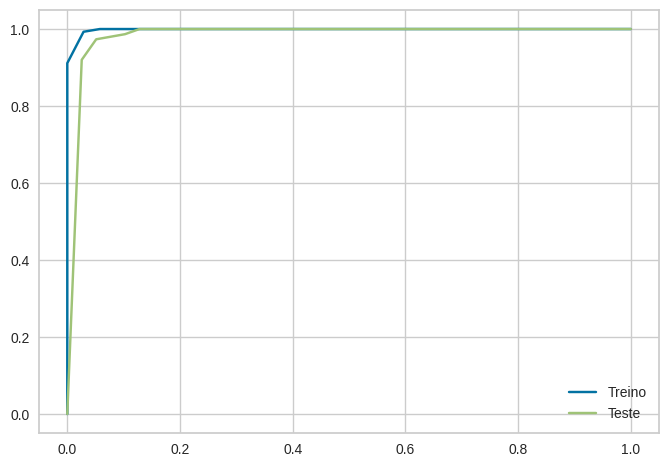

In [100]:
#plotando a curva roc

roc_train = roc_curve(y_train, prob_train[:,1])
roc_test = roc_curve(y_test, prob_test[:,1])
plt.plot(roc_train[0], roc_train[1], label='Treino')
plt.plot(roc_test[0], roc_test[1], label='Teste')
plt.legend()
plt.show()

# Aplicando o SHAP


In [101]:
#aplicando o shap para gerar a explicação

explainer = shap.KernelExplainer(knn.predict, shap.kmeans(X_train, 10))
shap_values = explainer.shap_values(X_test)

  0%|          | 0/114 [00:00<?, ?it/s]

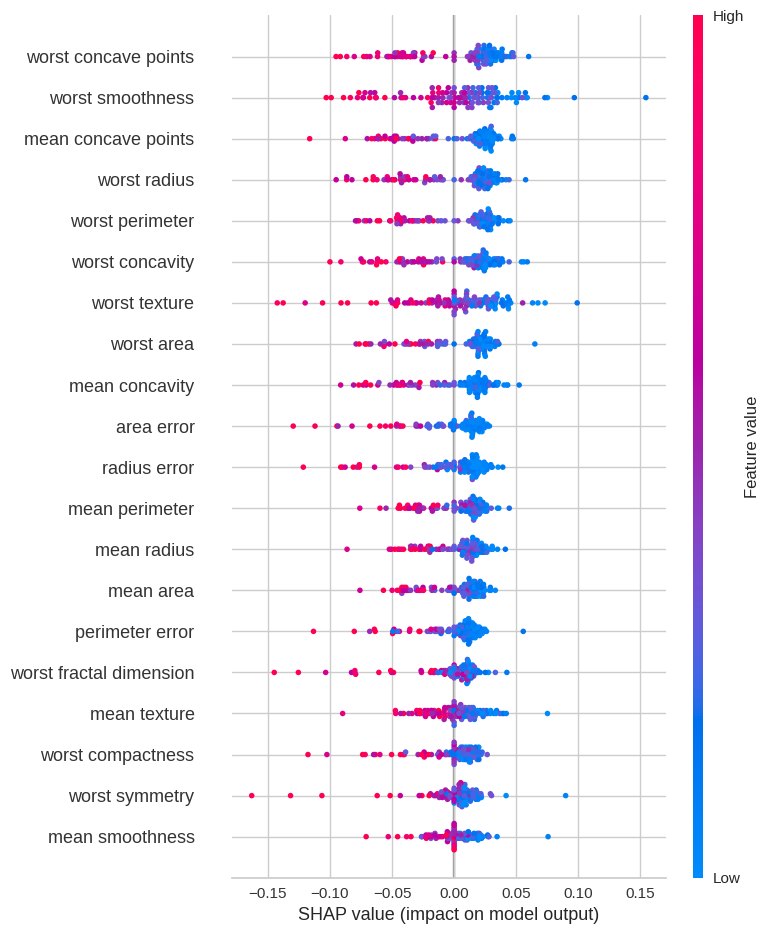

In [102]:
#plotando o gráfico
shap.summary_plot(shap_values, X_test, feature_names=data['feature_names'])

In [104]:
#plotando os valores de importância para cada característica

mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
feature_names = data['feature_names']
feature_importance = zip(feature_names, mean_abs_shap_values)

sorted_feature_importance = sorted(feature_importance, key= lambda x:x[1], reverse=True)
sorted_feature_importance

[('worst concave points', 0.033224662539099926),
 ('worst smoothness', 0.03191162702217337),
 ('mean concave points', 0.03074940935510832),
 ('worst radius', 0.030670233224137113),
 ('worst perimeter', 0.03008712714923152),
 ('worst concavity', 0.02972348252023276),
 ('worst texture', 0.02918711203956093),
 ('worst area', 0.026892211780320963),
 ('mean concavity', 0.02670442765318118),
 ('area error', 0.021707921483843397),
 ('radius error', 0.021405959226889235),
 ('mean perimeter', 0.019980942441305462),
 ('mean radius', 0.019561468418983912),
 ('mean area', 0.019364678183221518),
 ('perimeter error', 0.017953268907777743),
 ('worst fractal dimension', 0.017310391527576366),
 ('mean texture', 0.016778113310924613),
 ('worst compactness', 0.016725649248606377),
 ('worst symmetry', 0.014869238572084921),
 ('mean smoothness', 0.012821131854259305),
 ('mean compactness', 0.01072082200447074),
 ('mean symmetry', 0.007678443770884512),
 ('texture error', 0.0073948194667776464),
 ('mean fra